In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
#reddit_df = pd.read_csv('/home/jeremy/Teaching/intro_to_programming_and_ds/resources/data/100k_random_reddit_2018.csv')
reddit_df = pd.read_csv('../resources/data/100k_random_reddit_2018.csv')
reddit_df.created_utc = pd.to_datetime(reddit_df.created_utc, unit='s')
reddit_df = reddit_df.set_index('created_utc')

In [3]:
d = {"a":1, "b":2}

In [4]:
for x in d:
    print(x)

a
b


In [5]:
for k, v in d.items():
    if k == 'a':
        print(v)

1


### Exercise 1

Sort the data frame by score and select the rows with the 10th to 20th highest scores.


In [6]:
sorted_df = reddit_df.sort_values('score', ascending=False)

### Exercise 2

Now, how would you select just the `subreddit` and `comment_length` columns for the rows you selected above?

### Exercise 3

Find the average (mean) comment length for each subreddit and sort by comment length

### Exercise 4

Plot the number of comments and average score. Are frequent posters more likely to share comments that are well-received?

*Hint*: You will want to use a dataframe that groups the data by person

### Exercise 5

Plot the number of comments per month over the year.

In [18]:
reddit_df

,subreddit,author,comment_length,score
created_utc,,,,
2018-01-01 00:00:41,Astronomy,illuminatiisnowhere,50,3
2018-01-01 00:02:52,politics,ExtracurricularSpork,31,10
2018-01-01 00:03:37,frugalmalefashion,TheBarnhouseEffect,126,5
2018-01-01 00:06:57,KansasCityChiefs,thenewguyreddit,48,5
2018-01-01 00:09:20,Aeon,ribnag,385,1
...,...,...,...,...
2018-12-31 23:50:40,Shamanism,[deleted],215,3
2018-12-31 23:51:04,funny,PCDuranet,40,60
2018-12-31 23:52:57,feludasports,ManyYoung,116,1


Text(0, 0.5, 'Number of comments')

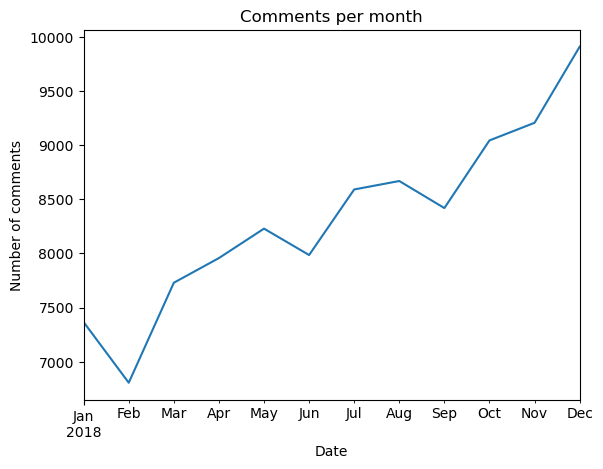

In [30]:
reddit_df.resample('ME').size().plot()
plt.title("Comments per month")
plt.xlabel("Date")
plt.ylabel("Number of comments")

In [31]:
plt.savefig('comments_per_month.png')

<Figure size 640x480 with 0 Axes>

### Exercise 6

See if you can figure out how to change the above plot so that instead of showing one overall line for comments per hour, it shows a line for each day of the week (e.g., a line for comments per hour on Mondays, another for Tuesdays, etc.).

This code can help you to get started: it sums the number of comments by hour and day.

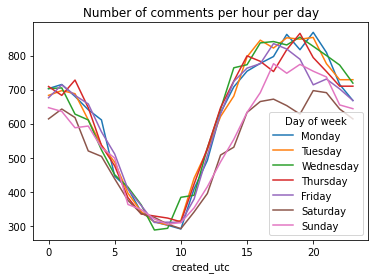

In [55]:
reddit_df.groupby([reddit_df.index.hour, reddit_df.index.day_of_week]).size().unstack().plot();
plt.title('Number of comments per hour per day')
plt.legend(title='Day of week', labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])